In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Classes: ['acai', 'graviola', 'guarana', 'tucuma', 'cupuacu', 'pupunha']


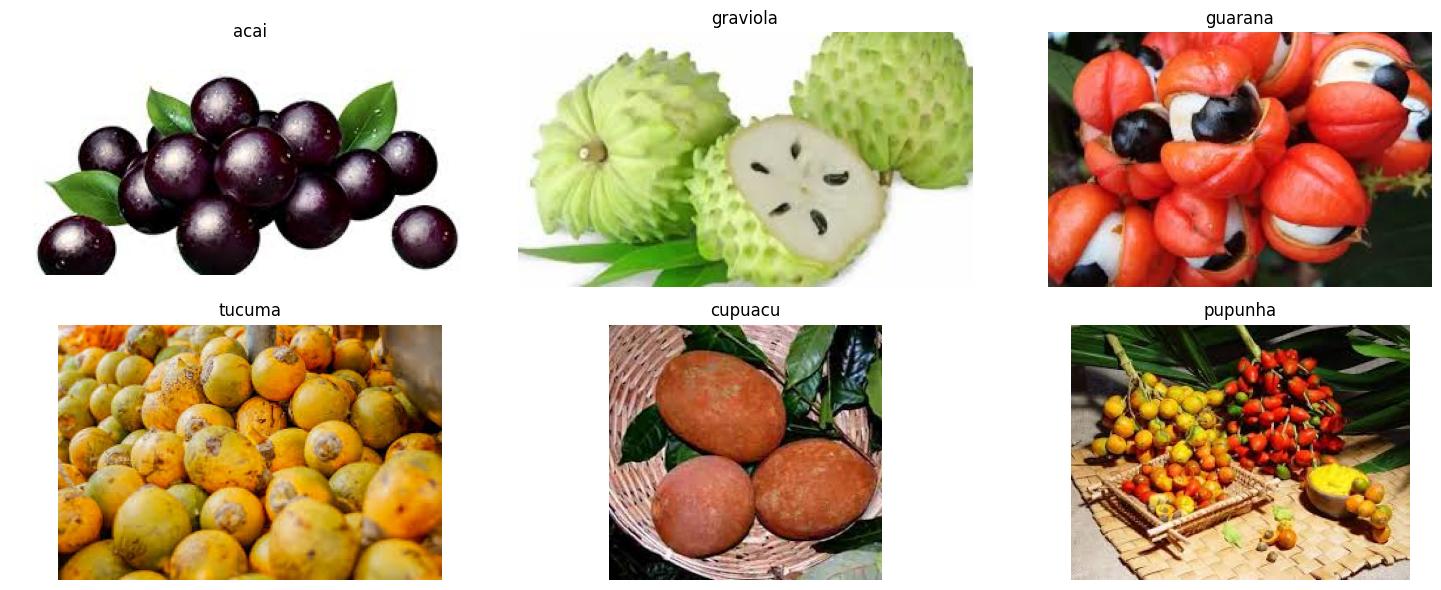

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 📁 Path to your dataset (update this)
train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"

# 1️⃣ Get class directories
classes = [cls for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))]

print("Classes:", classes)

# 2️⃣ Select one random image from each class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# 3️⃣ Display images in grid (2 rows)
num_images = len(images)
cols = (num_images // 2) + (num_images % 2)

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import os
from PIL import Image

#  Set correct path
train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"

corrupted_images = []

# Loop through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Loop through images
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening image
            with Image.open(img_path) as img:
                img.verify()  # verifies image integrity

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final output
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 741ms/step - accuracy: 0.1528 - loss: 2.2088 - val_accuracy: 0.8333 - val_loss: 1.4742
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 585ms/step - accuracy: 0.2361 - loss: 1.7814 - val_accuracy: 0.1667 - val_loss: 1.7248
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 726ms/step - accuracy: 0.2500 - loss: 1.7230 - val_accuracy: 0.0556 - val_loss: 1.6084
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3333 - loss: 1.5495 - val_accuracy: 0.6111 - val_loss: 1.2860
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 624ms/step - accuracy: 0.5278 - loss: 1.2166 - val_accuracy: 0.6667 - val_loss: 0.8548
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 602ms/step - accuracy: 0.7500 - loss: 0.8780 - val_accuracy: 0.6111 - val_loss: 0.8540
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 590ms/step - accuracy: 0.8333 - loss: 0.6084 - val_accuracy: 0.7778 - val_loss: 0.6979
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 594ms/step - accuracy: 0.8750 - loss: 0.3550 - val_accuracy: 0.5556 - val_loss: 1.3246
Epoch 

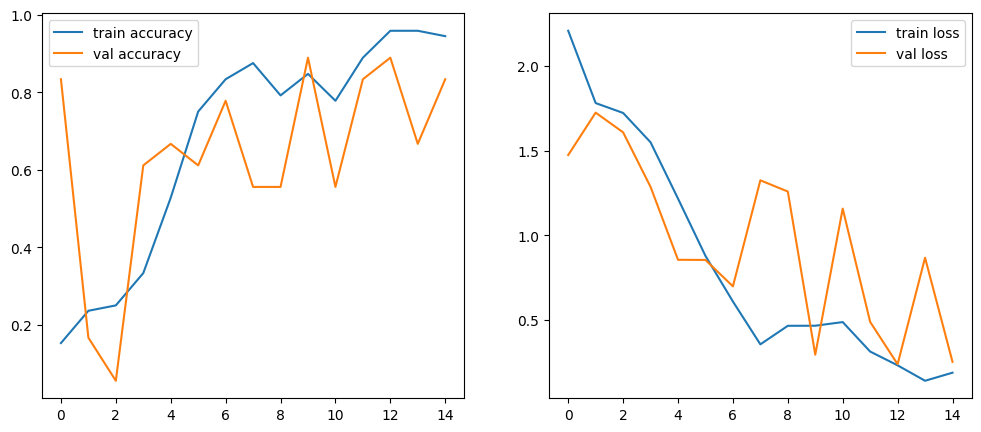

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = layers.Rescaling(1./255)

# Load original datasets first
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Get class names BEFORE mapping/prefetching
class_names = raw_train_ds.class_names
num_classes = len(class_names)

# Apply normalization
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds = raw_val_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = layers.Rescaling(1./255)

raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds = raw_val_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

model = models.Sequential([
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 836ms/step - accuracy: 0.1806 - loss: 2.6844 - val_accuracy: 0.8333 - val_loss: 1.1765
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - accuracy: 0.1944 - loss: 1.7896 - val_accuracy: 0.0556 - val_loss: 1.6922
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 0.3472 - loss: 1.6219 - val_accuracy: 0.3889 - val_loss: 1.4684
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - accuracy: 0.4444 - loss: 1.4653 - val_accuracy: 0.7222 - val_loss: 1.1900
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step - accuracy: 0.5972 - loss: 1.2769 - val_accuracy: 0.8889 - val_loss: 0.8611
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 388ms/step - accuracy: 0.6667 - loss: 1.0620 - val_accuracy: 0.6667 - val_loss: 0.8134
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 409ms/step - accuracy: 0.7361 - loss: 0.8135 - val_accuracy: 0.7778

In [18]:
# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train",
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train",
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

# Get number of classes BEFORE mapping
num_classes = len(train_ds.class_names)

# Normalize and prefetch
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ----------------------------
# Dataset paths
# ----------------------------
train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"  # replace with your path
val_dir   = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/test"  # replace with your path

# ----------------------------
# Load datasets
# ----------------------------
batch_size = 16
img_height = 128
img_width  = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ----------------------------
# Model definition
# ----------------------------
num_classes = len(train_ds.class_names)  # automatically detect number of classes

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),  # input layer
    layers.Rescaling(1./255),                        # normalize images
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# ----------------------------
# Compile model
# ----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# Callbacks
# ----------------------------
checkpoint_cb = ModelCheckpoint(
    "best_model.keras", save_best_only=True
)

earlystop_cb = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

# ----------------------------
# Train the model
# ----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1889 - loss: 2.0027 - val_accuracy: 0.3000 - val_loss: 1.7635
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 633ms/step - accuracy: 0.3222 - loss: 1.6939 - val_accuracy: 0.3667 - val_loss: 1.5367
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 456ms/step - accuracy: 0.5333 - loss: 1.4583 - val_accuracy: 0.6333 - val_loss: 1.2198
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step - accuracy: 0.6444 - loss: 1.0951 - val_accuracy: 0.5667 - val_loss: 1.0573
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step - accuracy: 0.6778 - loss: 0.8460 - val_accuracy: 0.6667 - val_loss: 0.9285
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 0.8000 - loss: 0.6591 - val_accuracy: 0.4667 - val_loss: 1.3235
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 608ms/step - accuracy: 0.7222 - loss: 0.6508 - val_accuracy: 0.6667 - val_loss: 0.9706
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━

In [24]:
import tensorflow as tf

# Paths to your folders
train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/test"

# Image dimensions
img_height = 128
img_width  = 128
batch_size = 16

# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7333 - loss: 0.6428
Test Loss: 0.6428
Test Accuracy: 0.7333


In [25]:
import tensorflow as tf

# --- Assuming your model is already trained and test_ds is loaded ---

# 1️⃣ Save the model to an HDF5 (.h5) file
model.save("my_trained_model.h5")
print("Model saved successfully!")

# 2️⃣ Load the saved model
loaded_model = tf.keras.models.load_model("my_trained_model.h5")
print("Model loaded successfully!")

# 3️⃣ Re-evaluate on the test dataset
test_loss, test_accuracy = loaded_model.evaluate(test_ds)
print(f"Test Loss (loaded model): {test_loss:.4f}")
print(f"Test Accuracy (loaded model): {test_accuracy:.4f}")

Model saved successfully!
Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7333 - loss: 0.6428
Test Loss (loaded model): 0.6428
Test Accuracy (loaded model): 0.7333


In [26]:
import numpy as np
from sklearn.metrics import classification_report

# 1️⃣ Get class names (ensure you have them from training dataset)
class_names = train_ds.class_names  # or manually list them if needed

# 2️⃣ Make predictions on the test set
y_pred_probs = loaded_model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # convert probabilities to class labels

# 3️⃣ Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 4️⃣ Generate Classification Report
report = classification_report(y_true, y_pred_labels, target_names=class_names)
print("Classification Report:\n")
print(report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.25      0.20      0.22         5
     cupuacu       0.20      0.40      0.27         5
    graviola       0.33      0.20      0.25         5
     guarana       0.12      0.20      0.15         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.15      0.17      0.15        30
weighted avg       0.15      0.17      0.15        30

